<a href="https://colab.research.google.com/github/yuvrajm4/261421_Introduction_To_ML_Safety/blob/main/exercise_solutions/Introduction_To_ML_Safety_Ex4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##4.5: ODD Coverage with k-Projection
You defined an ODD in Exercise Sheet 2. Now assess how well your test set covers this
ODD using k-projection coverage.

In [ ]:
!git clone https://github.com/kkirchheim/odd-coverage.git

Cloning into 'odd-coverage'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 30 (delta 9), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 12.82 KiB | 4.27 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import sys,os
import pandas as pd

sys.path.append("/content/odd-coverage")

from kprojection import KProjectionCoverage

##Load Test Data

In [11]:

TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"
print("Test folder exists:", os.path.exists(TEST_DIR))

test_df = pd.read_csv(TEST_DIR + "/labels.csv")

test_df.columns = [c.strip().lower() for c in test_df.columns]

display(test_df.head())

Test folder exists: True


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


## Create ODD columns from the test data

Since the dataset is CARLA clear daytime urban driving, we assign fixed ODD values.

In [13]:
odd_df = test_df.copy()

# ODD values based on dataset exploration
odd_df["weather"] = "clear"
odd_df["lighting"] = "day"
odd_df["camera_condition"] = "clean_forward"
odd_df["scene_type"] = "urban"

# Object labels from the dataset
odd_df["pedestrian"] = odd_df["has_pedestrian"].astype(int)
odd_df["traffic_light"] = odd_df["has_traffic_light"].astype(int)
odd_df["vehicle"] = odd_df["has_vehicle"].astype(int)

display(odd_df.head())

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle,weather,lighting,camera_condition,scene_type,pedestrian,traffic_light,vehicle
0,0,False,False,False,15,0,35,clear,day,clean_forward,urban,0,0,0
1,10,True,False,True,299,0,116,clear,day,clean_forward,urban,0,1,1
2,20,True,False,True,298,0,307,clear,day,clean_forward,urban,0,1,1
3,30,True,False,True,297,0,258,clear,day,clean_forward,urban,0,1,1
4,40,True,False,True,297,0,249,clear,day,clean_forward,urban,0,1,1


## Creating ODD as defined in Exercise - 2

In [14]:
description = {
    "weather": [
        "clear",
        "cloudy",
        "rain",
        "fog",
        "snow",
        "hail"
    ],

    "lighting": [
        "day",
        "night",
        "dusk_dawn",
        "tunnel",
        "glare"
    ],

    "camera_condition": [
        "clean_forward",
        "dirty",
        "obstructed",
        "tilted",
        "wet_lens"
    ],

    "scene_type": [
        "urban",
        "highway",
        "offroad",
        "construction"
    ],

    "pedestrian": [
        0,
        1
    ],

    "traffic_light": [
        0,
        1
    ],

    "vehicle": [
        0,
        1
    ]
}

In [15]:
scenario_columns = list(description.keys())

scenarios = odd_df[scenario_columns].to_dict(orient="records")

print("Number of scenarios:", len(scenarios))
print(scenarios[0])

Number of scenarios: 3600
{'weather': 'clear', 'lighting': 'day', 'camera_condition': 'clean_forward', 'scene_type': 'urban', 'pedestrian': 0, 'traffic_light': 0, 'vehicle': 0}


##k-projection Coverage - Combinations

In [16]:
results = []

for k in [1, 2, 3]:

    cov = KProjectionCoverage(
        k=k,
        desc=description
    )

    cov.add_scenarios(scenarios)

    result = cov.compute()

    results.append({
        "k": result.k,
        "coverage": result.coverage,
        "covered_combinations": result.covered,
        "total_combinations": result.total,
        "number_of_test_scenarios": result.scenes
    })

coverage_df = pd.DataFrame(results)

display(coverage_df)

,k,coverage,covered_combinations,total_combinations,number_of_test_scenarios
0,1,0.384615,10,26,3600
1,2,0.149466,42,281,3600
2,3,0.058824,96,1632,3600


##Percentage Calculation as the k value is increased (the combinations are increased)

In [17]:
coverage_df["coverage_percent"] = coverage_df["coverage"] * 100

display(coverage_df)

,k,coverage,covered_combinations,total_combinations,number_of_test_scenarios,coverage_percent
0,1,0.384615,10,26,3600,38.461538
1,2,0.149466,42,281,3600,14.946619
2,3,0.058824,96,1632,3600,5.882353


In [18]:
for _, row in coverage_df.iterrows():
    print(
        f"k={int(row['k'])}: "
        f"{row['covered_combinations']} / {row['total_combinations']} combinations covered "
        f"= {row['coverage_percent']:.2f}%"
    )

k=1: 10.0 / 26.0 combinations covered = 38.46%
k=2: 42.0 / 281.0 combinations covered = 14.95%
k=3: 96.0 / 1632.0 combinations covered = 5.88%


###4.7: Per-Class Evaluation Evaluate each of your three models on the provided test set.
1. Compute and report precision, recall, and F1-score for each model.
2. Plot a confusion matrix for each model.

In [19]:
import os
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [20]:
TEST_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/test"

MODEL_DIR = "/content/drive/MyDrive/introduction_to_ml_safety/trained_models"
PEDESTRIAN_MODEL_PATH = os.path.join(MODEL_DIR, "pedestrian_detector.pth")
TRAFFIC_LIGHT_MODEL_PATH = os.path.join(MODEL_DIR, "traffic_light_detector.pth")
VEHICLE_MODEL_PATH = os.path.join(MODEL_DIR, "vehicle_detector.pth")

In [21]:
test_df = pd.read_csv(os.path.join(TEST_DIR, "labels.csv"))

test_df.columns = [c.strip().lower() for c in test_df.columns]

display(test_df.head())
print(test_df.columns)

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [23]:
def build_image_path(root_dir, frame):
    filename = f"{int(frame):06d}.jpg"
    return os.path.join(root_dir, "rgb-front", filename)

In [24]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [25]:
class CarlaBinaryDataset(Dataset):

    def __init__(self, dataframe, root_dir, label_column, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        img_path = build_image_path(
            self.root_dir,
            row["frame"]
        )

        image = Image.open(img_path).convert("RGB")

        label = torch.tensor(
            float(row[self.label_column]),
            dtype=torch.float32
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [26]:
def create_model():
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )

    num_features = model.fc.in_features

    model.fc = nn.Linear(num_features, 1)

    model = model.to(device)

    return model

###LOAD SAVED MODELS

In [27]:
pedestrian_model = create_model()
pedestrian_model.load_state_dict(
    torch.load(PEDESTRIAN_MODEL_PATH, map_location=device)
)
pedestrian_model.eval()


traffic_light_model = create_model()
traffic_light_model.load_state_dict(
    torch.load(TRAFFIC_LIGHT_MODEL_PATH, map_location=device)
)
traffic_light_model.eval()


vehicle_model = create_model()
vehicle_model.load_state_dict(
    torch.load(VEHICLE_MODEL_PATH, map_location=device)
)
vehicle_model.eval()

print("All saved models loaded successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.1MB/s]


All saved models loaded successfully.


In [28]:
def evaluate_model_with_confusion_matrix(
    model,
    label_column,
    model_name,
    batch_size=32,
    threshold=0.5
):

    print(f"\nEvaluating: {model_name}")

    test_dataset = CarlaBinaryDataset(
        dataframe=test_df,
        root_dir=TEST_DIR,
        label_column=label_column,
        transform=test_transform
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    all_labels = []
    all_predictions = []

    model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            probabilities = torch.sigmoid(outputs)

            predictions = (probabilities > threshold).int()

            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.numpy().flatten()
            )

    precision = precision_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        zero_division=0
    )

    cm = confusion_matrix(
        all_labels,
        all_predictions
    )

    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Absent", "Present"]
    )

    disp.plot(values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return {
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

###Evaluation and putting values in confusion matrix


Evaluating: Pedestrian Detector
Precision: 0.4527
Recall   : 0.3385
F1-score : 0.3874


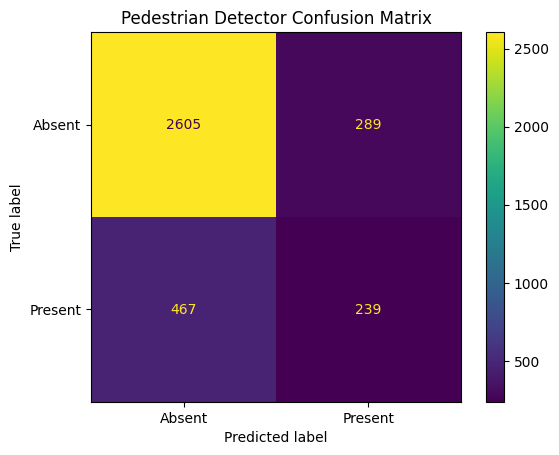


Evaluating: Traffic Light Detector
Precision: 0.9419
Recall   : 0.9717
F1-score : 0.9566


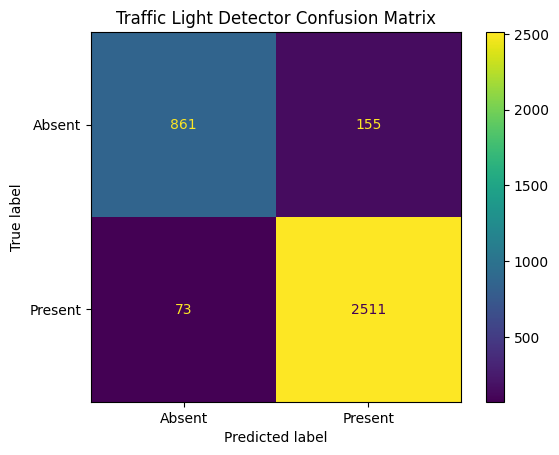


Evaluating: Vehicle Detector
Precision: 0.9558
Recall   : 0.8893
F1-score : 0.9213


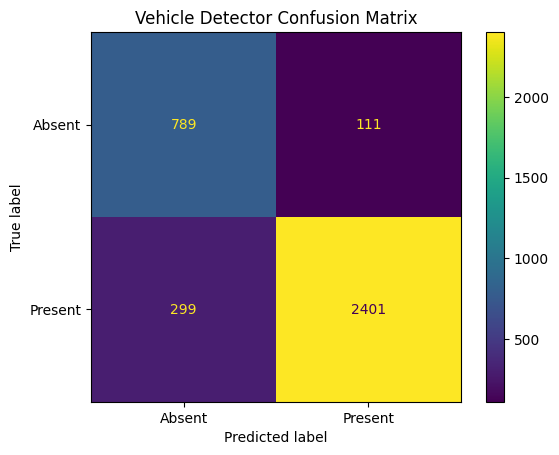

In [29]:
pedestrian_results = evaluate_model_with_confusion_matrix(
    model=pedestrian_model,
    label_column="has_pedestrian",
    model_name="Pedestrian Detector"
)

traffic_light_results = evaluate_model_with_confusion_matrix(
    model=traffic_light_model,
    label_column="has_traffic_light",
    model_name="Traffic Light Detector"
)

vehicle_results = evaluate_model_with_confusion_matrix(
    model=vehicle_model,
    label_column="has_vehicle",
    model_name="Vehicle Detector"
)

In [30]:
results_df = pd.DataFrame([
    pedestrian_results,
    traffic_light_results,
    vehicle_results
])

display(results_df)

,Model,Precision,Recall,F1-score
0,Pedestrian Detector,0.452652,0.338527,0.387358
1,Traffic Light Detector,0.941860,0.971749,0.956571
2,Vehicle Detector,0.955812,0.889259,0.921335




3. Which model has the lowest recall? Is this the model you expected to be hardest based on your hazard analysis?

→
The Pedestrian Detector has the lowest recall: 0.3385.
Yes, this is the model I expected to be hardest. Pedestrian detection is difficult because pedestrians are often:

Reason
Explanation
Small in the image
Pedestrians may appear far away and occupy only a few pixels.
Visually variable
Pedestrians have different poses, clothes, sizes, and orientations.
Sometimes occluded
They may be partly hidden behind vehicles or other objects.
Less frequent
The dataset likely contains fewer pedestrian examples compared to vehicles or traffic lights.



4. Based on a safety argument: what minimum recall would you require for the pedestrian model before considering deployment? Justify your threshold.
→

From a safety perspective, I would require the pedestrian detector to achieve at least 99% recall before considering deployment, and only within the validated ODD. The reason is that false negatives are the most dangerous error for pedestrian detection. If the model misses a real pedestrian, the planning module may not brake, which can lead directly to hazard H-1 and potentially to injury or death. Therefore, the recall threshold must come from the hazard analysis, not from the current model performance. Since the current pedestrian recall is only about 33.85%, the model is clearly not suitable for deployment.
